# Análisis de tráfico web
Este cuaderno consulta los registros HTTP almacenados en PostgreSQL y genera estadísticas.

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, URL, text

url = URL.create(
    'postgresql+psycopg',
    username=os.environ['POSTGRES_USER'],
    password=os.environ['POSTGRES_PASSWORD'],
    host='database',
    port=5432,
    database=os.environ['POSTGRES_DB']
)
engine = create_engine(url)
print('Conexión preparada')

Conexión preparada


In [5]:
consulta = '''
SELECT ts, client_ip, method, path, status, bytes_sent
FROM nginx_requests
ORDER BY ts DESC
LIMIT 1000
'''
with engine.connect() as conn:
    resultado = conn.execute(text(consulta))
    df = pd.DataFrame(resultado.fetchall(), columns=list(resultado.keys()))
print('Registros obtenidos:', len(df))
display(df.head(10))

Registros obtenidos: 739


,ts,client_ip,method,path,status,bytes_sent
0,2026-10-02 23:31:03+00:00,172.20.0.1,GET,/jupyter/static/favicons/favicon-busy-1.ico,304,0
1,2026-10-02 23:31:02+00:00,172.20.0.1,GET,/jupyter/api/contents?content=1&1790983862537,200,721
2,2026-10-02 23:31:02+00:00,172.20.0.1,GET,/jupyter/api/contents?content=1&1790983862334,200,721
3,2026-10-02 23:31:00+00:00,172.20.0.1,GET,/jupyter/api/kernels?1790983860867,200,320
4,2026-10-02 23:30:59+00:00,172.20.0.1,GET,/jupyter/api/terminals?1790983859360,200,2
5,2026-10-02 23:30:55+00:00,172.20.0.1,GET,/jupyter/api/nbconvert?1790983854422,200,631
6,2026-10-02 23:30:55+00:00,172.20.0.1,PUT,/jupyter/lab/api/workspaces/default?1790983855609,204,0
7,2026-10-02 23:30:55+00:00,172.20.0.1,GET,/jupyter/static/favicons/favicon-busy-1.ico,304,0
8,2026-10-02 23:30:55+00:00,172.20.0.1,GET,/jupyter/static/favicons/favicon-busy-1.ico,304,0
9,2026-10-02 23:30:55+00:00,172.20.0.1,GET,/jupyter/static/favicons/favicon-busy-1.ico,304,0


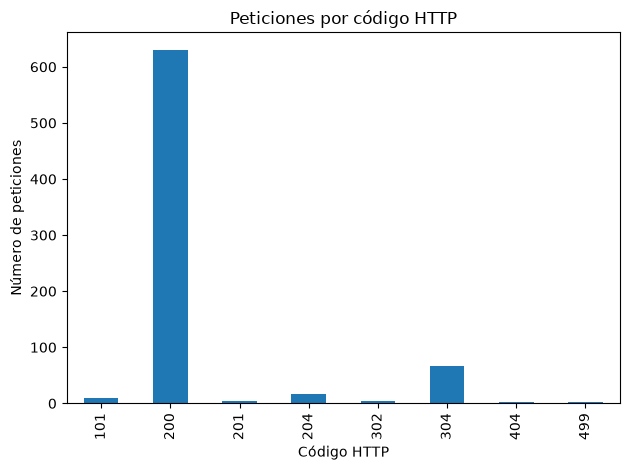

In [6]:
if not df.empty:
    df.groupby('status').size().sort_index().plot(kind='bar')
    plt.title('Peticiones por código HTTP')
    plt.xlabel('Código HTTP')
    plt.ylabel('Número de peticiones')
    plt.tight_layout()
    plt.show()
else:
    print('Todavía no hay peticiones registradas. Visita el portal y vuelve a ejecutar esta celda.')

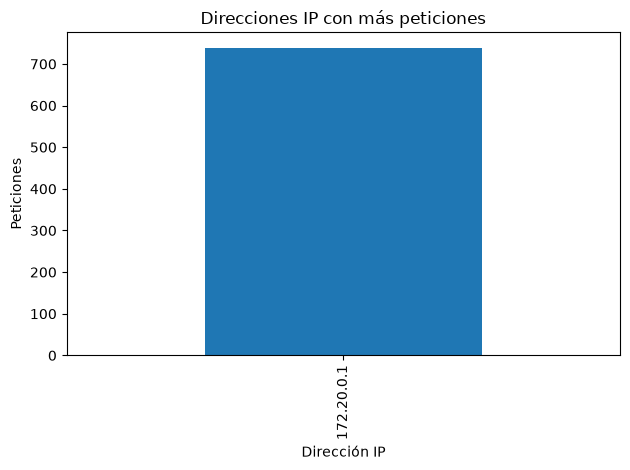

In [7]:
if not df.empty:
    df.groupby('client_ip').size().sort_values(ascending=False).head(10).plot(kind='bar')
    plt.title('Direcciones IP con más peticiones')
    plt.xlabel('Dirección IP')
    plt.ylabel('Peticiones')
    plt.tight_layout()
    plt.show()